In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/vedte_mamoaio/Downloads/amazon_sales_dataset.csv")
df.head()

,Order ID,Order Date,Product Name,Category,Price,Quantity,Customer Location,Payment Method,Total Sales
0,1001,2023-01-01,Camera,Electronics,29125,4,Hyderabad,Credit Card,116500
1,1002,2023-01-02,Shoes,Accessories,16004,4,Bangalore,UPI,64016
2,1003,2023-01-03,T-shirt,Accessories,24589,4,Pune,Debit Card,98356
3,1004,2023-01-04,Watch,Electronics,36987,3,Mumbai,UPI,110961
4,1005,2023-01-05,Camera,Electronics,802,1,Mumbai,Debit Card,802


## Data Cleaning

In [3]:
# Check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Order ID           1000 non-null   int64 
 1   Order Date         1000 non-null   object
 2   Product Name       1000 non-null   object
 3   Category           1000 non-null   object
 4   Price              1000 non-null   int64 
 5   Quantity           1000 non-null   int64 
 6   Customer Location  1000 non-null   object
 7   Payment Method     1000 non-null   object
 8   Total Sales        1000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [4]:
# Convert date
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [5]:
df['Order Date']

0     2023-01-01
1     2023-01-02
2     2023-01-03
3     2023-01-04
4     2023-01-05
         ...    
995   2025-09-22
996   2025-09-23
997   2025-09-24
998   2025-09-25
999   2025-09-26
Name: Order Date, Length: 1000, dtype: datetime64[ns]

In [6]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [7]:
# Null values
df.isnull().sum()

Order ID             0
Order Date           0
Product Name         0
Category             0
Price                0
Quantity             0
Customer Location    0
Payment Method       0
Total Sales          0
dtype: int64

## Feature Engineering

In [8]:
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

In [9]:
df['Month']

0      1
1      1
2      1
3      1
4      1
      ..
995    9
996    9
997    9
998    9
999    9
Name: Month, Length: 1000, dtype: int32

In [10]:
df['Year']

0      2023
1      2023
2      2023
3      2023
4      2023
       ... 
995    2025
996    2025
997    2025
998    2025
999    2025
Name: Year, Length: 1000, dtype: int32

## EDA (Main Analysis)

#### Total Sales

In [11]:
total_sales = df['Total Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 63801190


#### Sales by Category

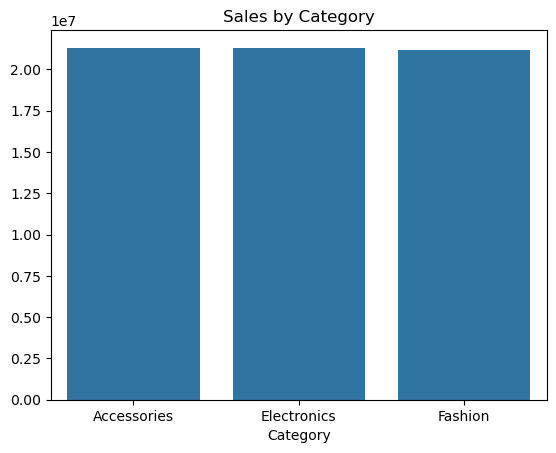

In [12]:
category_sales = df.groupby('Category')['Total Sales'].sum().sort_values(ascending=False)

sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Sales by Category")
plt.show()

#### Monthly Sales Trend

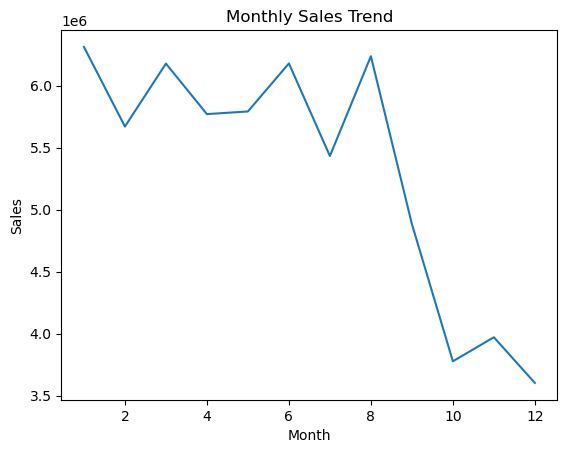

In [13]:
monthly_sales = df.groupby('Month')['Total Sales'].sum()

plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

#### Top 10 Products

In [14]:
top_products = df.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False).head(10)

print(top_products)

Product Name
Laptop        293
Headphones    282
Speaker       280
Watch         274
Backpack      244
T-shirt       240
Camera        238
Tablet        225
Smartphone    210
Shoes         204
Name: Quantity, dtype: int64


#### Sales by Location

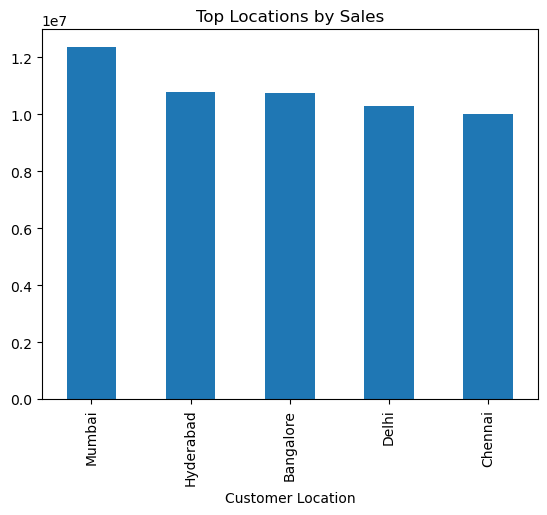

In [15]:
location_sales = df.groupby('Customer Location')['Total Sales'].sum().sort_values(ascending=False)

location_sales.head(5).plot(kind='bar')
plt.title("Top Locations by Sales")
plt.show()

#### Payment Method Analysis

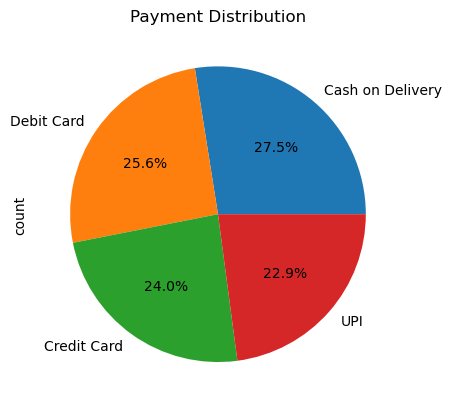

In [16]:
payment = df['Payment Method'].value_counts()

payment.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Distribution")
plt.show()

## Adding Profit Calculation

In [17]:
df['Cost Price'] = df['Price'] * 0.7
df['Profit'] = df['Total Sales'] - (df['Cost Price'] * df['Quantity'])

#### Profit Analysis

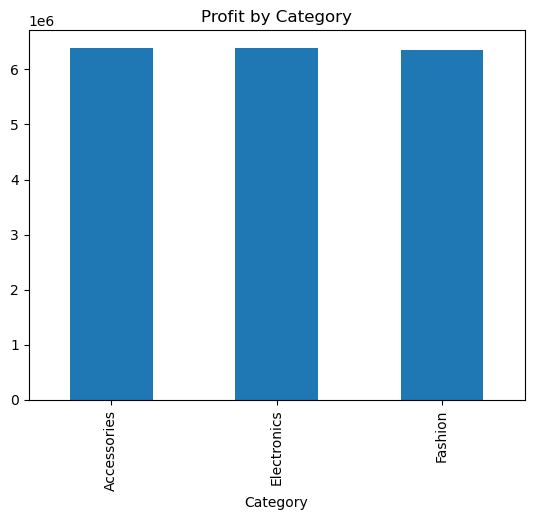

In [19]:
profit_by_category = df.groupby('Category')['Profit'].sum()

profit_by_category.plot(kind='bar', title="Profit by Category")
plt.show()

#### Customer Segmentation

In [20]:
import datetime as dt

latest_date = df['Order Date'].max()

rfm = df.groupby('Order ID').agg({
    'Order Date': lambda x: (latest_date - x.max()).days,
    'Order ID': 'count',
    'Total Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [21]:
rfm['Segment'] = pd.qcut(rfm['Monetary'], 4, labels=[
    'Low Value', 'Mid Value', 'High Value', 'Premium'
])

In [22]:
rfm['Segment'] 

Order ID
1001       Premium
1002    High Value
1003       Premium
1004       Premium
1005     Low Value
           ...    
1996     Low Value
1997    High Value
1998     Low Value
1999       Premium
2000     Mid Value
Name: Segment, Length: 1000, dtype: category
Categories (4, object): ['Low Value' < 'Mid Value' < 'High Value' < 'Premium']

In [23]:
df.head()

,Order ID,Order Date,Product Name,Category,Price,Quantity,Customer Location,Payment Method,Total Sales,Month,Year,Cost Price,Profit
0,1001,2023-01-01,Camera,Electronics,29125,4,Hyderabad,Credit Card,116500,1,2023,20387.5,34950.0
1,1002,2023-01-02,Shoes,Accessories,16004,4,Bangalore,UPI,64016,1,2023,11202.8,19204.8
2,1003,2023-01-03,T-shirt,Accessories,24589,4,Pune,Debit Card,98356,1,2023,17212.3,29506.8
3,1004,2023-01-04,Watch,Electronics,36987,3,Mumbai,UPI,110961,1,2023,25890.9,33288.3
4,1005,2023-01-05,Camera,Electronics,802,1,Mumbai,Debit Card,802,1,2023,561.4,240.6
